# 03 — Training Actions Analysis

This notebook analyses historical training activity and measures operational pressure for each course-location combination.

The analysis examines:

1. the distribution of training actions across courses, locations, modalities, statuses, and professional areas;
2. recent and historical training volume;
3. changes in monthly activity;
4. the recurrence and regularity of training demand;
5. concurrent actions and simultaneous active days;
6. the relative operational pressure of each course-location combination.

The final output is a training-actions pressure score that contributes to the overall hiring-priority model.

In [56]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

## Project configuration

The notebook reads the validated training-action and course-reference datasets from `data/processed/`.

The operational features and pressure scores are exported to `data/scores/` for integration with the workforce and commercial dimensions.

In [57]:
PROCESSED_DATA_DIR = Path("../data/processed")

SCORES_DATA_DIR = Path("../data/scores")

## Data import

Two processed datasets are used:

- `training_actions.csv`: action identifiers, courses, locations, dates, modalities, statuses, and learner totals;
- `info_actions.csv`: course names, professional areas, reference durations, and catalogue status.

Date columns are parsed during import to support monthly aggregation, trend analysis, recurrence measurement, and daily simultaneity calculations.

In [58]:
training_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "training_actions.csv", sep=",", encoding="utf-8", parse_dates=["start_date", "end_date"])


info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

## Analytical training-action base

Training actions are combined with the course-reference dataset. Inactive catalogue courses and duplicated action-location-status records are removed.

At this stage, all action statuses are retained to describe the complete dataset. A narrower analytical scope is defined later for the operational-pressure model.

In [59]:
actions_analysis_df = training_actions_df.merge(
    info_actions_df, how="inner", on="course_id", validate="many_to_one"
)

actions_analysis_df = actions_analysis_df.loc[actions_analysis_df["active"]].drop_duplicates(subset=["action_id", "local", "status"])

actions_analysis_df

,action_id,course_id,local,start_date,end_date,modality,status,total_students,course_name,course_area,total_hours,active
0,P_HCP_0001,HCP,Centro 1,2018-01-01,2018-01-02,In-person,Finalizada,11,HACCP Aplicado,Alimentar,12,True
1,P_INF_0001,INF,Centro 1,2018-01-01,2018-01-03,In-person,Finalizada,11,"Infeção, Prevenção e Controlo",Saúde,16,True
2,P_PRI_0001,PRI,Centro 1,2018-01-01,2018-01-03,In-person,Finalizada,15,Primeiros Socorros,Saúde e Segurança,12,True
3,H_TUR_0004,TUR,Centro 5,2018-01-01,2018-01-05,Hybrid,Finalizada,20,Atendimento Turístico,Turismo,16,True
4,H_INF_0005,INF,Centro 5,2018-01-01,2018-01-06,Hybrid,Finalizada,20,"Infeção, Prevenção e Controlo",Saúde,16,True
...,...,...,...,...,...,...,...,...,...,...,...,...
19120,P_HAC_0778,HAC,Centro 4,2026-12-30,2026-12-31,In-person,Prevista,25,Higiene e Segurança Alimentar,Alimentar,8,True
19121,H_ING_0583,ING,Centro 2,2026-12-30,2026-12-31,Hybrid,Prevista,21,Inglês Profissional,Línguas,30,True
19122,E_PRO_0618,PRO,Centro 4,2026-12-30,2026-12-31,Online,Prevista,31,Gestão de Projetos,Gestão,25,True
19123,P_SCI_0684,SCI,Centro 3,2026-12-30,2026-12-31,In-person,Prevista,21,Segurança Contra Incêndios,Segurança,8,True


## Training activity overview

The complete dataset contains 19,125 training actions across:

- 4 action statuses;
- 3 delivery modalities;
- 5 training centres;
- 24 active courses;
- a time span from 2018 to 2026.

This overview includes completed, ongoing, cancelled, and planned actions. It describes the full dataset but is not yet the input used to calculate operational pressure.

In [60]:
total_actions = actions_analysis_df["action_id"].nunique()
total_status = actions_analysis_df["status"].nunique()
total_modalities = actions_analysis_df["modality"].nunique()
total_time = (
    actions_analysis_df["end_date"].max() - actions_analysis_df["start_date"].min()
).days / 365

print(
    f"""
Total Actions: {total_actions}
Number of Status: {total_status}
Number of Modalities: {total_modalities}
Period of Time: {total_time:.0f} years
""".strip()
)

Total Actions: 19125
Number of Status: 4
Number of Modalities: 3
Period of Time: 9 years


## Distribution of training activity

A reusable summary function calculates:

- number of distinct actions;
- total learners;
- percentage of actions;
- percentage of learners.

Training activity is then examined by course, location, status, modality, professional area, and combinations of these variables.

These summaries identify how operational activity is distributed before recent and historical features are calculated.

In [61]:
def summarize_actions(df, group_columns):
    summary = (
        df
        .groupby(group_columns, as_index=False)
        .agg(
            actions_count=("action_id", "nunique"),
            students_count=("total_students", "sum")
        )
        .assign(
            pct_actions=lambda data:
                data["actions_count"]
                .div(data["actions_count"].sum())
                .mul(100)
                .round(1),

            pct_students=lambda data:
                data["students_count"]
                .div(data["students_count"].sum())
                .mul(100)
                .round(1)
        )
        .sort_values(
            by="actions_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return summary

In [62]:
actions_course_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name"]
)

actions_course_count

,course_id,course_name,actions_count,students_count,pct_actions,pct_students
0,CYB,Cibersegurança Básica,1214,25214,6.3,7.0
1,PBI,Power BI e Visualização de Dados,1209,25308,6.3,7.0
2,SEG,Segurança no Trabalho,1069,20473,5.6,5.7
3,EXC,Excel Aplicado à Gestão,1024,21029,5.4,5.8
4,SST,Saúde e Segurança no Trabalho,1012,19273,5.3,5.3
5,PRI,Primeiros Socorros,953,16724,5.0,4.6
6,GER,Geriatria e Apoio ao Idoso,937,16200,4.9,4.5
7,LOG,Logística e Gestão de Armazém,909,16084,4.8,4.4
8,MNT,Manutenção Industrial Básica,851,14091,4.4,3.9
9,PYT,Introdução à Programação em Python,789,16572,4.1,4.6


In [63]:
actions_local_count = summarize_actions(
    actions_analysis_df,
    ["local"]
)

actions_local_count

,local,actions_count,students_count,pct_actions,pct_students
0,Centro 2,4090,78532,21.4,21.7
1,Centro 4,3845,73373,20.1,20.3
2,Centro 1,3818,71843,20.0,19.8
3,Centro 5,3741,69936,19.6,19.3
4,Centro 3,3631,68253,19.0,18.9


In [64]:
actions_status_count = summarize_actions(
    actions_analysis_df,
    ["status"]
)

actions_status_count

,status,actions_count,students_count,pct_actions,pct_students
0,Finalizada,16619,323260,86.9,89.3
1,Prevista,1582,34344,8.3,9.5
2,Cancelada,866,3035,4.5,0.8
3,Em andamento,58,1298,0.3,0.4


In [65]:
actions_modalities_count = summarize_actions(
    actions_analysis_df,
    ["modality"]
)

actions_modalities_count

,modality,actions_count,students_count,pct_actions,pct_students
0,In-person,9357,154288,48.9,42.6
1,Hybrid,6188,120835,32.4,33.4
2,Online,3580,86814,18.7,24.0


In [66]:
actions_area_count = summarize_actions(
    actions_analysis_df,
    ["course_area"]
)

actions_area_count

,course_area,actions_count,students_count,pct_actions,pct_students
0,Informática,4236,88123,22.1,24.3
1,Segurança,3372,62005,17.6,17.1
2,Gestão,1999,39791,10.5,11.0
3,Saúde,1627,28153,8.5,7.8
4,Alimentar,1480,26839,7.7,7.4
5,Saúde e Segurança,1433,25091,7.5,6.9
6,Turismo,1195,20827,6.2,5.8
7,Logística,909,16084,4.8,4.4
8,Manutenção,851,14091,4.4,3.9
9,Comercial,754,14901,3.9,4.1


In [67]:
actions_course_local_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "local"]
)

actions_course_local_count

,course_id,course_name,local,actions_count,students_count,pct_actions,pct_students
0,PBI,Power BI e Visualização de Dados,Centro 4,324,6768,1.7,1.9
1,CYB,Cibersegurança Básica,Centro 4,320,6615,1.7,1.8
2,PBI,Power BI e Visualização de Dados,Centro 2,319,6718,1.7,1.9
3,CYB,Cibersegurança Básica,Centro 2,307,6190,1.6,1.7
4,SEG,Segurança no Trabalho,Centro 5,268,5103,1.4,1.4
...,...,...,...,...,...,...,...
115,HOT,Housekeeping e Operações Hoteleiras,Centro 4,85,1440,0.4,0.4
116,SOC,Socorrismo Básico,Centro 2,84,1470,0.4,0.4
117,TUR,Atendimento Turístico,Centro 3,83,1354,0.4,0.4
118,SOC,Socorrismo Básico,Centro 1,67,1215,0.4,0.3


In [68]:
actions_course_modality_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "modality"]
)

actions_course_modality_count.head(25)

,course_id,course_name,modality,actions_count,students_count,pct_actions,pct_students
0,MNT,Manutenção Industrial Básica,In-person,851,14091,4.4,3.9
1,PRI,Primeiros Socorros,In-person,640,10623,3.3,2.9
2,GER,Geriatria e Apoio ao Idoso,In-person,615,10135,3.2,2.8
3,EMP,Empilhadores e Movimentação de Cargas,In-person,606,10046,3.2,2.8
4,LOG,Logística e Gestão de Armazém,In-person,590,9821,3.1,2.7
5,SEG,Segurança no Trabalho,In-person,541,9068,2.8,2.5
6,PBI,Power BI e Visualização de Dados,Online,517,12423,2.7,3.4
7,SST,Saúde e Segurança no Trabalho,In-person,507,8405,2.7,2.3
8,CYB,Cibersegurança Básica,Online,486,11692,2.5,3.2
9,HCP,HACCP Aplicado,In-person,474,7701,2.5,2.1


In [69]:
actions_course_status_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "status"]
)

actions_course_status_count.head(25)

,course_id,course_name,status,actions_count,students_count,pct_actions,pct_students
0,CYB,Cibersegurança Básica,Finalizada,1031,22056,5.4,6.1
1,PBI,Power BI e Visualização de Dados,Finalizada,1023,22061,5.3,6.1
2,SEG,Segurança no Trabalho,Finalizada,955,18705,5.0,5.2
3,SST,Saúde e Segurança no Trabalho,Finalizada,890,17333,4.7,4.8
4,EXC,Excel Aplicado à Gestão,Finalizada,874,18813,4.6,5.2
5,PRI,Primeiros Socorros,Finalizada,834,15025,4.4,4.2
6,LOG,Logística e Gestão de Armazém,Finalizada,800,14464,4.2,4.0
7,GER,Geriatria e Apoio ao Idoso,Finalizada,797,14231,4.2,3.9
8,MNT,Manutenção Industrial Básica,Finalizada,728,12363,3.8,3.4
9,HAC,Higiene e Segurança Alimentar,Finalizada,686,13384,3.6,3.7


In [70]:
actions_local_modalities_count = summarize_actions(
    actions_analysis_df,
    ["local", "modality"]
)

actions_local_modalities_count

,local,modality,actions_count,students_count,pct_actions,pct_students
0,Centro 5,In-person,1947,32229,10.2,8.9
1,Centro 1,In-person,1901,31051,9.9,8.6
2,Centro 3,In-person,1869,30910,9.8,8.5
3,Centro 2,In-person,1864,30932,9.7,8.5
4,Centro 4,In-person,1776,29166,9.3,8.1
5,Centro 2,Hybrid,1357,26411,7.1,7.3
6,Centro 1,Hybrid,1244,24464,6.5,6.8
7,Centro 4,Hybrid,1241,24277,6.5,6.7
8,Centro 5,Hybrid,1174,22733,6.1,6.3
9,Centro 3,Hybrid,1172,22950,6.1,6.3


In [71]:
actions_local_status_count = summarize_actions(
    actions_analysis_df,
    ["local", "status"]
)

actions_local_status_count

,local,status,actions_count,students_count,pct_actions,pct_students
0,Centro 2,Finalizada,3536,69961,18.5,19.3
1,Centro 4,Finalizada,3345,65690,17.5,18.1
2,Centro 1,Finalizada,3336,64402,17.4,17.8
3,Centro 5,Finalizada,3245,62297,17.0,17.2
4,Centro 3,Finalizada,3157,60910,16.5,16.8
5,Centro 2,Prevista,358,7683,1.9,2.1
6,Centro 5,Prevista,313,6747,1.6,1.9
7,Centro 1,Prevista,306,6733,1.6,1.9
8,Centro 4,Prevista,305,6650,1.6,1.8
9,Centro 3,Prevista,300,6531,1.6,1.8


In [72]:
actions_modality_status_count = summarize_actions(
    actions_analysis_df,
    ["modality", "status"]
)

actions_modality_status_count

,modality,status,actions_count,students_count,pct_actions,pct_students
0,In-person,Finalizada,8150,138171,42.6,38.2
1,Hybrid,Finalizada,5384,107813,28.2,29.8
2,Online,Finalizada,3085,77276,16.1,21.4
3,In-person,Prevista,751,14365,3.9,4.0
4,Hybrid,Prevista,523,11633,2.7,3.2
5,In-person,Cancelada,445,1559,2.3,0.4
6,Online,Prevista,308,8346,1.6,2.3
7,Hybrid,Cancelada,259,921,1.4,0.3
8,Online,Cancelada,162,555,0.8,0.2
9,Online,Em andamento,25,637,0.1,0.2


In [73]:
all_actions_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "local", "modality", "status"]
)

all_actions_count

,course_id,course_name,local,modality,status,actions_count,students_count,pct_actions,pct_students
0,MNT,Manutenção Industrial Básica,Centro 1,In-person,Finalizada,192,3155,1.0,0.9
1,MNT,Manutenção Industrial Básica,Centro 5,In-person,Finalizada,171,2921,0.9,0.8
2,GER,Geriatria e Apoio ao Idoso,Centro 3,In-person,Finalizada,157,2710,0.8,0.7
3,PRI,Primeiros Socorros,Centro 3,In-person,Finalizada,155,2685,0.8,0.7
4,MNT,Manutenção Industrial Básica,Centro 4,In-person,Finalizada,149,2558,0.8,0.7
...,...,...,...,...,...,...,...,...,...
879,GER,Geriatria e Apoio ao Idoso,Centro 4,Hybrid,Em andamento,1,24,0.0,0.0
880,SST,Saúde e Segurança no Trabalho,Centro 1,Online,Cancelada,1,7,0.0,0.0
881,PYT,Introdução à Programação em Python,Centro 5,In-person,Em andamento,1,15,0.0,0.0
882,PYT,Introdução à Programação em Python,Centro 5,Online,Cancelada,1,5,0.0,0.0


In [74]:
all_actions_count[["actions_count", "students_count"]].describe().round(2)

,actions_count,students_count
count,884.00,884.00
mean,21.63,409.43
std,29.98,579.17
min,1.00,0.00
25%,3.00,18.00
50%,6.00,103.00
75%,35.00,717.00
max,192.00,3155.00


## Training activity visualisation

A reusable plotting function is created to compare action counts and their percentage distribution across categorical variables.

The overview visualisation presents:

- courses with the greatest number of actions;
- distribution across training centres;
- distribution by action status;
- distribution by delivery modality.

The complete dataset contains 16,619 completed actions, 1,582 planned actions, 866 cancelled actions, and 58 ongoing actions. In-person training is the most frequent modality, followed by hybrid and online delivery.

In [75]:
def plot_actions_overview(charts, title, ylabel="Number of Actions", nrows=2, ncols=2, figsize=(13, 9)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy()

        if "top_n" in chart:
            plot_df = plot_df.head(chart["top_n"])

        categories = plot_df[chart["label_column"]].astype(str)
        values = plot_df["actions_count"]
        percentages = plot_df["pct_actions"]

        bars = ax.bar(categories, values)

        labels = [
            f"{value}\n({percentage:.1f}%)"
            for value, percentage in zip(values, percentages)
        ]

        ax.bar_label(bars, labels=labels, padding=4, fontsize=8)

        ax.set_title(chart["title"], loc="left", fontweight="bold", pad=25)

        ax.text(
            0,
            1.02,
            chart["description"],
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_facecolor("#FFFFFF")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, values.max() * 1.25)

        ax.tick_params(axis="x", rotation=45)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3)

    plt.show()

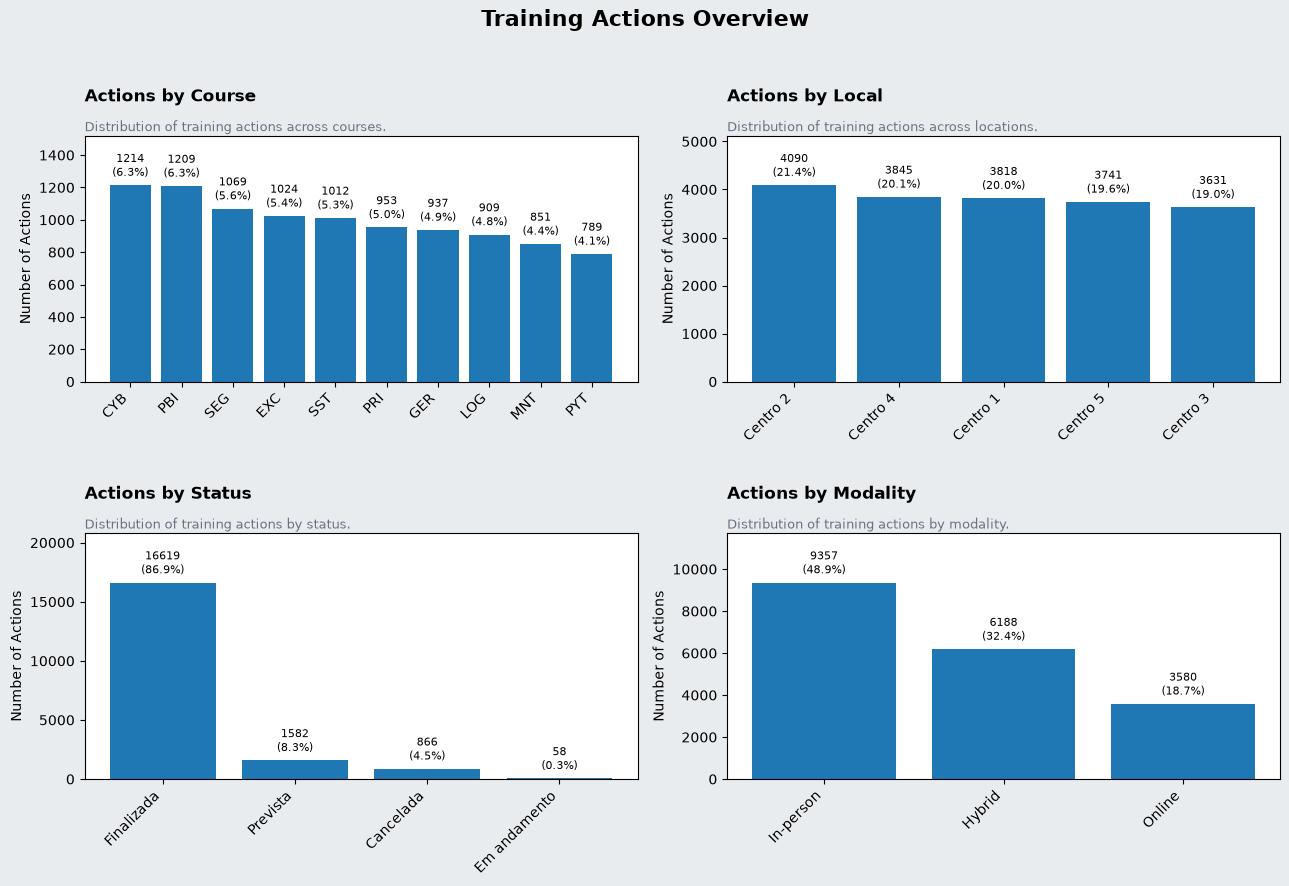

In [76]:
actions_overview_charts = {
    "courses": {
        "df": actions_course_count,
        "label_column": "course_id",
        "title": "Actions by Course",
        "description": "Distribution of training actions across courses.",
        "top_n": 10
    },

    "locals": {
        "df": actions_local_count,
        "label_column": "local",
        "title": "Actions by Local",
        "description": "Distribution of training actions across locations."
    },

    "status": {
        "df": actions_status_count,
        "label_column": "status",
        "title": "Actions by Status",
        "description": "Distribution of training actions by status."
    },

    "modalities": {
        "df": actions_modalities_count,
        "label_column": "modality",
        "title": "Actions by Modality",
        "description": "Distribution of training actions by modality."
    }
}

plot_actions_overview(
    charts=actions_overview_charts,
    title="Training Actions Overview"
)

## Operational feature scope

The pressure model uses only completed and ongoing actions. Cancelled actions are excluded because they did not generate effective operational demand, while planned actions are excluded because this score is intended to describe observed activity.

The analysis date is 29 July 2026. To avoid using an incomplete month, June 2026 is defined as the latest reference month.

Two periods are compared:

- **Last 12 months:** July 2025 to June 2026;
- **Historical:** January 2018 to June 2025.

Only actions starting on or before 30 June 2026 are retained for feature construction.

In [77]:
group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


actions_features_base = (
    actions_analysis_df
    .loc[
        actions_analysis_df["status"].isin(["Finalizada", "Em andamento"]),
        group_columns + [
            "action_id",
            "start_date",
            "end_date",
            "total_hours"
        ]
    ]
    .copy()
)

actions_features_base["end_date"] = (
    actions_features_base["end_date"]
    .fillna(actions_features_base["start_date"])
)

actions_features_base["action_month"] = (
    actions_features_base["start_date"]
    .dt.to_period("M")
)

ANALYSIS_DATE = pd.Timestamp("2026-07-29")

reference_month = ANALYSIS_DATE.to_period("M") - 1
last_12m_start_month = reference_month - 11
reference_date = reference_month.end_time.normalize()

actions_features_base = (
    actions_features_base
    .loc[
        actions_features_base["start_date"]
        .le(reference_date)
    ]
    .copy()
)

actions_features_base["period"] = "historical"

actions_features_base.loc[
    actions_features_base["action_month"]
    .ge(last_12m_start_month),
    "period"
] = "last_12m"


course_local_combinations = (
    actions_features_base[group_columns]
    .drop_duplicates()
    .reset_index(drop=True)
)


print(
    f"Last 12 months: "
    f"{last_12m_start_month} - {reference_month}"
)

print(
    f"Historical: {actions_features_base["start_date"].min().date()} - {last_12m_start_month - 1}"
)

Last 12 months: 2025-07 - 2026-06
Historical: 2018-01-01 - 2025-06


## Complete monthly time series

A complete sequence of months is generated for every course-location combination, including months without training activity.

Missing monthly observations are filled with zero actions and zero training hours. This is essential for measuring:

- true monthly averages;
- periods without activity;
- regularity;
- growth trends.

Without these zero-activity months, the model would overestimate operational frequency and continuity.

In [78]:
all_months_df = pd.DataFrame({
    "action_month": pd.period_range(
        start=actions_features_base["action_month"].min(),
        end=reference_month,
        freq="M"
    )
})


monthly_actions_count_df = (
    actions_features_base
    .groupby(
        group_columns + ["action_month"],
        as_index=False
    )
    .agg(
        actions_count=(
            "action_id",
            "nunique"
        ),

        training_hours=(
            "total_hours",
            "sum"
        )
    )
)


actions_monthly_df = (
    course_local_combinations
    .merge(
        all_months_df,
        how="cross"
    )
    .merge(
        monthly_actions_count_df,
        on=group_columns + ["action_month"],
        how="left",
        validate="one_to_one"
    )
    .fillna({
        "actions_count": 0,
        "training_hours": 0
    })
)


actions_monthly_df["actions_count"] = (
    actions_monthly_df["actions_count"]
    .astype(int)
)


actions_monthly_df["period"] = "historical"

actions_monthly_df.loc[
    actions_monthly_df["action_month"]
    .ge(last_12m_start_month),
    "period"
] = "last_12m"


actions_monthly_df = (
    actions_monthly_df
    .sort_values(
        group_columns + ["action_month"]
    )
    .reset_index(drop=True)
)


actions_monthly_df["active_month"] = (
    actions_monthly_df["actions_count"]
    .gt(0)
    .astype(int)
)

actions_monthly_df

,course_id,course_name,course_area,local,action_month,actions_count,training_hours,period,active_month
0,CYB,Cibersegurança Básica,Informática,Centro 1,2018-01,1,16.0,historical,1
1,CYB,Cibersegurança Básica,Informática,Centro 1,2018-02,0,0.0,historical,0
2,CYB,Cibersegurança Básica,Informática,Centro 1,2018-03,0,0.0,historical,0
3,CYB,Cibersegurança Básica,Informática,Centro 1,2018-04,0,0.0,historical,0
4,CYB,Cibersegurança Básica,Informática,Centro 1,2018-05,1,16.0,historical,1
...,...,...,...,...,...,...,...,...,...
12235,VND,Vendas e Negociação,Comercial,Centro 5,2026-02,2,32.0,last_12m,1
12236,VND,Vendas e Negociação,Comercial,Centro 5,2026-03,2,32.0,last_12m,1
12237,VND,Vendas e Negociação,Comercial,Centro 5,2026-04,2,32.0,last_12m,1
12238,VND,Vendas e Negociação,Comercial,Centro 5,2026-05,2,32.0,last_12m,1


## Evolution of training activity

Monthly activity is visualised at two levels:

- total actions by training centre;
- total actions across the organisation.

The plots show the evolution of operational demand and help identify changes in activity levels over the full analytical period.

In [79]:
def plot_actions_trends(charts, title, nrows=1, ncols=2, figsize=(15, 6)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = (
            chart["df"]
            .copy()
            .sort_values(
                chart["sort_columns"]
            )
        )

        if "rolling_window" in chart:

            plot_df["plot_value"] = (
                plot_df
                .groupby(
                    chart["group_column"]
                )[chart["value_column"]]
                .transform(
                    lambda series:
                        series
                        .rolling(
                            window=chart["rolling_window"],
                            min_periods=1
                        )
                        .mean()
                )
            )

            value_column = "plot_value"

        else:
            value_column = chart["value_column"]

        for group, group_df in plot_df.groupby(
            chart["group_column"],
            sort=True
        ):

            ax.plot(group_df[chart["date_column"]], group_df[value_column], label=group, linewidth=1.8)

        ax.set_title(chart["title"], loc="left", fontweight="bold", pad=25)

        ax.text(0, 1.02, chart["description"], transform=ax.transAxes, fontsize=9, color="#6B7280")

        ax.set_facecolor("#FFFFFF")

        ax.set_xlabel("Date")
        ax.set_ylabel(chart["ylabel"])

        ax.set_ylim(bottom=0)

        ax.grid(axis="y", alpha=0.2)

        ax.tick_params(axis="x", rotation=45)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

        if plot_df[chart["group_column"]].nunique() > 1:

            ax.legend(title=chart["legend_title"], frameon=False, fontsize=8, title_fontsize=9, ncol=2)

    for ax in axes.flat[len(charts):]:
        ax.set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.93], w_pad=3)

    plt.show()

In [80]:
actions_location_monthly_df = (
    actions_monthly_df
    .groupby(
        [
            "local",
            "action_month"
        ],
        as_index=False
    )
    .agg(
        actions_count=(
            "actions_count",
            "sum"
        )
    )
    .assign(
        month_date=lambda df:
            df["action_month"]
            .dt.to_timestamp()
    )
    .sort_values(
        [
            "local",
            "action_month"
        ]
    )
    .reset_index(drop=True)
)

actions_total_monthly_df = (
    actions_monthly_df
    .groupby(
        "action_month",
        as_index=False
    )
    .agg(
        actions_count=(
            "actions_count",
            "sum"
        )
    )
    .assign(
        month_date=lambda df:
            df["action_month"]
            .dt.to_timestamp(),

        series="Total"
    )
    .sort_values("action_month")
    .reset_index(drop=True)
)

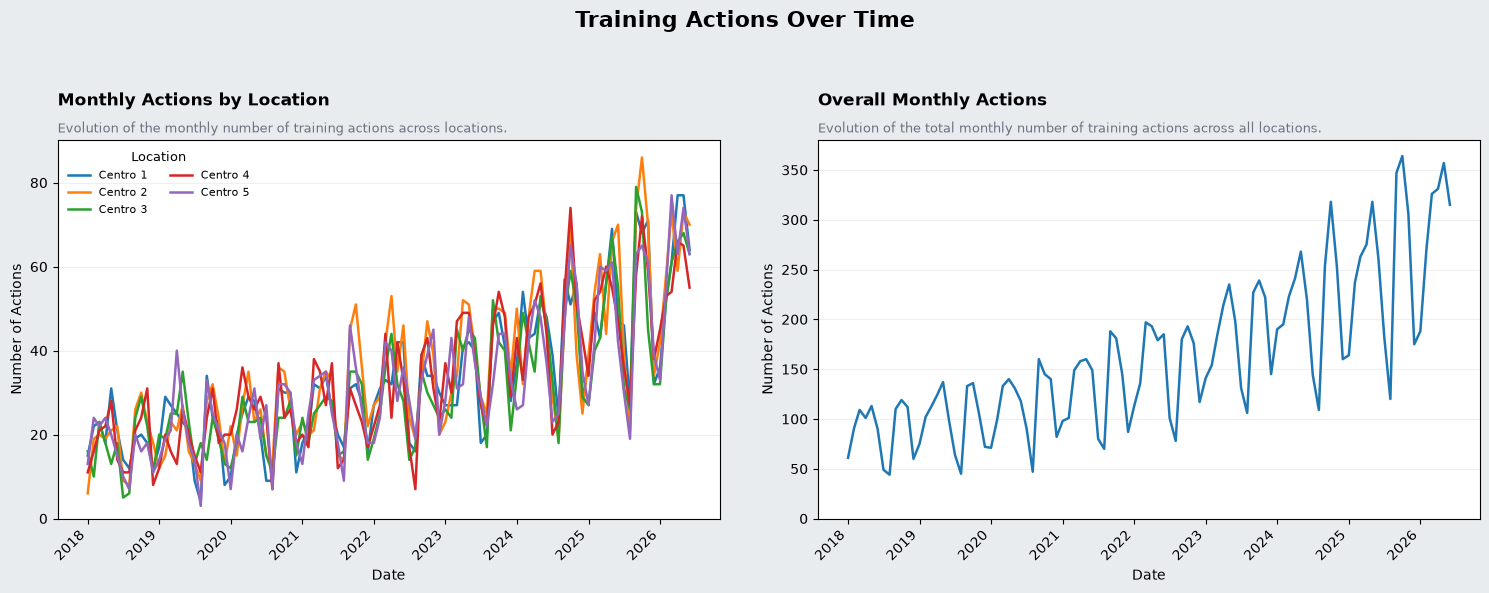

In [81]:
actions_temporal_charts = {
    "by_location": {
        "df": actions_location_monthly_df,
        "date_column": "month_date",
        "value_column": "actions_count",
        "group_column": "local",
        "sort_columns": [
            "local",
            "month_date"
        ],
        "title": "Monthly Actions by Location",
        "description": (
            "Evolution of the monthly number of training actions "
            "across locations."
        ),
        "ylabel": "Number of Actions",
        "legend_title": "Location"
    },

    "overall": {
        "df": actions_total_monthly_df,
        "date_column": "month_date",
        "value_column": "actions_count",
        "group_column": "series",
        "sort_columns": [
            "month_date"
        ],
        "title": "Overall Monthly Actions",
        "description": (
            "Evolution of the total monthly number of training actions "
            "across all locations."
        ),
        "ylabel": "Number of Actions",
        "legend_title": "Series"
    }
}


plot_actions_trends(
    charts=actions_temporal_charts,
    title="Training Actions Over Time",
    nrows=1,
    ncols=2,
    figsize=(15, 6)
)

## Operational feature engineering

Five complementary dimensions are created for each course-location combination:

1. **Volume:** average monthly actions and reference training hours;
2. **Growth:** direction and intensity of the monthly activity trend;
3. **Recurrence:** typical interval between the start of consecutive actions;
4. **Regularity:** proportion of months containing at least one action;
5. **Simultaneity:** peak concurrent actions and proportion of active days with overlapping actions.

Each dimension is calculated separately for the last 12 months and the historical period.

### Volume

Operational volume is represented by:

- average number of actions per month;
- average reference training hours per month.

The training-hour measure uses the reference duration associated with each course. It represents estimated instructional demand rather than recorded trainer working hours.

In [82]:
volume_last_12m_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_avg_last_12m=(
            "actions_count",
            "mean"
        ),

        training_hours_monthly_avg_last_12m=(
            "training_hours",
            "mean"
        )
    )
)


volume_historical_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_avg_historical=(
            "actions_count",
            "mean"
        ),

        training_hours_monthly_avg_historical=(
            "training_hours",
            "mean"
        )
    )
)


actions_volume_features_df = (
    course_local_combinations
    .merge(
        volume_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        volume_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_volume_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,training_hours_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,2.333333,28.000000,1.077778,12.933333
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,1.500000,24.000000,0.755556,12.088889
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,3.083333,37.000000,1.922222,23.066667
3,TUR,Atendimento Turístico,Turismo,Centro 5,2.333333,37.333333,1.000000,16.000000
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,1.416667,22.666667,0.844444,13.511111
...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,2.416667,38.666667,0.900000,14.400000
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3.333333,53.333333,2.088889,33.422222
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,2.000000,50.000000,1.388889,34.722222
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,2.500000,40.000000,1.300000,20.800000


### Growth

Growth is estimated through the linear trend of monthly action counts.

A positive value indicates increasing activity, a negative value indicates decreasing activity, and a value close to zero indicates relative stability. Trends are calculated separately for the recent and historical periods.

In [83]:
def calculate_monthly_trend(actions_count):

    actions_count = actions_count.reset_index(drop=True)

    month_index = pd.Series(range(len(actions_count)), dtype="float64")

    if len(actions_count) < 2:
        return 0.0

    trend = (actions_count.cov(month_index) / month_index.var())

    return trend


growth_last_12m_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("last_12m")
    ]
    .sort_values(
        group_columns + ["action_month"]
    )
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_trend_last_12m=(
            "actions_count",
            calculate_monthly_trend
        )
    )
)


growth_historical_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("historical")
    ]
    .sort_values(
        group_columns + ["action_month"]
    )
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_trend_historical=(
            "actions_count",
            calculate_monthly_trend
        )
    )
)


actions_growth_features_df = (
    course_local_combinations
    .merge(
        growth_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        growth_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_growth_features_df

,course_id,course_name,course_area,local,actions_monthly_trend_last_12m,actions_monthly_trend_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,0.174825,0.009293
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,0.069930,0.007063
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,0.066434,0.015483
3,TUR,Atendimento Turístico,Turismo,Centro 5,0.202797,0.014059
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,0.024476,0.011672
...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,0.087413,0.005622
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,0.342657,0.027444
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,0.076923,0.013854
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,-0.055944,0.025690


### Recurrence

Recurrence measures the median number of days between distinct action start dates for each course-location combination.

Shorter intervals indicate more frequent operational demand. The score therefore treats fewer days between actions as greater pressure.

In [84]:
action_dates_df = (
    actions_features_base[
        group_columns + [
            "start_date",
            "period"
        ]
    ]
    .drop_duplicates(
        subset=group_columns + ["start_date"]
    )
    .sort_values(
        group_columns + [
            "period",
            "start_date"
        ]
    )
    .reset_index(drop=True)
)


action_dates_df["days_between_actions"] = (
    action_dates_df
    .groupby(
        group_columns + ["period"]
    )["start_date"]
    .diff()
    .dt.days
)


recurrence_last_12m_df = (
    action_dates_df
    .loc[
        action_dates_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        median_days_between_actions_last_12m=(
            "days_between_actions",
            "median"
        )
    )
)


recurrence_historical_df = (
    action_dates_df
    .loc[
        action_dates_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        median_days_between_actions_historical=(
            "days_between_actions",
            "median"
        )
    )
)


actions_recurrence_features_df = (
    course_local_combinations
    .merge(
        recurrence_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        recurrence_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_recurrence_features_df

,course_id,course_name,course_area,local,median_days_between_actions_last_12m,median_days_between_actions_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,12.0,21.0
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,14.0,28.0
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,7.0,13.0
3,TUR,Atendimento Turístico,Turismo,Centro 5,12.0,22.5
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,18.5,24.0
...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,9.0,21.0
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,8.0,13.0
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,14.0,14.0
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,6.5,19.5


### Regularity

Regularity is measured as the proportion of months containing at least one training action.

A high active-month ratio indicates sustained operational demand, while a lower ratio indicates intermittent or occasional activity.

In [85]:
regularity_last_12m_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        active_month_ratio_last_12m=(
            "active_month",
            "mean"
        )
    )
)


regularity_historical_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        active_month_ratio_historical=(
            "active_month",
            "mean"
        )
    )
)


actions_regularity_features_df = (
    course_local_combinations
    .merge(
        regularity_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        regularity_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_regularity_features_df

,course_id,course_name,course_area,local,active_month_ratio_last_12m,active_month_ratio_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,0.833333,0.666667
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,0.833333,0.477778
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,1.000000,0.788889
3,TUR,Atendimento Turístico,Turismo,Centro 5,1.000000,0.622222
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,0.916667,0.555556
...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,0.916667,0.577778
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,1.000000,0.788889
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,0.833333,0.722222
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,0.750000,0.711111


### Simultaneity

Each training action is expanded into one row for every calendar day between its start and end dates.

For each course-location combination, the analysis calculates:

- the maximum number of actions active on the same day;
- the number of active action days;
- the number of days containing at least two simultaneous actions;
- the percentage of active days with simultaneous actions.

This is a planning approximation because detailed timetables and actual delivery days are not available.

In [86]:
simultaneity_daily_df = (
    actions_features_base[
        group_columns + [
            "action_id",
            "start_date",
            "end_date"
        ]
    ]
    .assign(
        action_date=lambda df:
            df.apply(
                lambda row:
                    pd.date_range(
                        start=row["start_date"],
                        end=row["end_date"],
                        freq="D"
                    ),
                axis=1
            )
    )
    .explode("action_date")
)


simultaneity_daily_df["action_date"] = (
    pd.to_datetime(
        simultaneity_daily_df["action_date"]
    )
)

simultaneity_daily_df = (
    simultaneity_daily_df
    .loc[
        simultaneity_daily_df["action_date"]
        .le(reference_date)
    ]
    .copy()
)


simultaneity_daily_df["action_month"] = (
    simultaneity_daily_df["action_date"]
    .dt.to_period("M")
)


simultaneity_daily_df["period"] = "historical"

simultaneity_daily_df.loc[
    simultaneity_daily_df["action_month"]
    .ge(last_12m_start_month),
    "period"
] = "last_12m"


simultaneity_daily_df = (
    simultaneity_daily_df
    .groupby(
        group_columns + [
            "period",
            "action_date"
        ],
        as_index=False
    )
    .agg(
        concurrent_actions=(
            "action_id",
            "nunique"
        )
    )
)


simultaneity_daily_df

,course_id,course_name,course_area,local,period,action_date,concurrent_actions
0,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-10,1
1,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-11,1
2,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-12,1
3,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-13,1
4,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-14,1
...,...,...,...,...,...,...,...
76398,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-06-17,1
76399,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-06-18,1
76400,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-06-19,1
76401,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-06-20,1


In [87]:
simultaneity_last_12m_df = (
    simultaneity_daily_df
    .loc[
        simultaneity_daily_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        peak_concurrent_actions_last_12m=(
            "concurrent_actions",
            "max"
        ),

        active_action_days_last_12m=(
            "action_date",
            "nunique"
        ),

        simultaneous_action_days_last_12m=(
            "concurrent_actions",
            lambda series:
                series.ge(2).sum()
        )
    )
    .assign(
        pct_simultaneous_action_days_last_12m=lambda df:
            df["simultaneous_action_days_last_12m"]
            .div(df["active_action_days_last_12m"])
            .mul(100)
            .round(1)
    )
)


simultaneity_historical_df = (
    simultaneity_daily_df
    .loc[
        simultaneity_daily_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        peak_concurrent_actions_historical=(
            "concurrent_actions",
            "max"
        ),

        active_action_days_historical=(
            "action_date",
            "nunique"
        ),

        simultaneous_action_days_historical=(
            "concurrent_actions",
            lambda series:
                series.ge(2).sum()
        )
    )
    .assign(
        pct_simultaneous_action_days_historical=lambda df:
            df["simultaneous_action_days_historical"]
            .div(df["active_action_days_historical"])
            .mul(100)
            .round(1)
    )
)


actions_simultaneity_features_df = (
    course_local_combinations
    .merge(
        simultaneity_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        simultaneity_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


simultaneity_count_columns = [
    "peak_concurrent_actions_last_12m",
    "active_action_days_last_12m",
    "simultaneous_action_days_last_12m",
    "peak_concurrent_actions_historical",
    "active_action_days_historical",
    "simultaneous_action_days_historical"
]


simultaneity_pct_columns = [
    "pct_simultaneous_action_days_last_12m",
    "pct_simultaneous_action_days_historical"
]


actions_simultaneity_features_df[
    simultaneity_count_columns
] = (
    actions_simultaneity_features_df[
        simultaneity_count_columns
    ]
    .fillna(0)
    .astype(int)
)


actions_simultaneity_features_df[
    simultaneity_pct_columns
] = (
    actions_simultaneity_features_df[
        simultaneity_pct_columns
    ]
    .fillna(0)
    .round(1)
)


actions_simultaneity_features_df

,course_id,course_name,course_area,local,peak_concurrent_actions_last_12m,active_action_days_last_12m,simultaneous_action_days_last_12m,pct_simultaneous_action_days_last_12m,peak_concurrent_actions_historical,active_action_days_historical,simultaneous_action_days_historical,pct_simultaneous_action_days_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,3,63,8,12.7,2,276,15,5.4
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,2,59,7,11.9,3,255,29,11.4
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,2,93,15,16.1,3,447,77,17.2
3,TUR,Atendimento Turístico,Turismo,Centro 5,4,90,21,23.3,2,317,43,13.6
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,2,63,2,3.2,3,278,24,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,3,127,16,12.6,3,389,34,8.7
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3,150,38,25.3,4,723,150,20.7
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,4,83,19,22.9,3,513,47,9.2
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,5,82,19,23.2,4,405,74,18.3


## Consolidated operational features

The five feature groups are combined into a single dataset containing one row for each course-location combination.

The resulting analytical base contains 120 combinations and 18 recent and historical operational features.

In [88]:
actions_features_df = (
    course_local_combinations
    .merge(
        actions_volume_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_growth_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_recurrence_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_regularity_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_simultaneity_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        ["local", "course_id"]
    )
    .reset_index(drop=True)
)


actions_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,training_hours_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_historical,actions_monthly_trend_last_12m,actions_monthly_trend_historical,...,active_month_ratio_last_12m,active_month_ratio_historical,peak_concurrent_actions_last_12m,active_action_days_last_12m,simultaneous_action_days_last_12m,pct_simultaneous_action_days_last_12m,peak_concurrent_actions_historical,active_action_days_historical,simultaneous_action_days_historical,pct_simultaneous_action_days_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,4.833333,77.333333,1.444444,23.111111,0.139860,0.029189,...,1.000000,0.700000,4,230,93,40.4,4,663,97,14.6
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,2.333333,37.333333,1.244444,19.911111,0.000000,0.010223,...,0.916667,0.644444,2,74,22,29.7,3,352,48,13.6
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,2.916667,58.333333,1.188889,23.777778,0.017483,0.020966,...,0.833333,0.666667,3,140,63,45.0,3,605,88,14.5
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,0.833333,75.000000,0.933333,84.000000,0.048951,0.011969,...,0.500000,0.566667,3,136,57,41.9,4,1236,400,32.4
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,2.750000,137.500000,1.022222,51.111111,0.080420,0.013286,...,0.833333,0.666667,4,199,81,40.7,4,727,126,17.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,3.666667,29.333333,2.211111,17.688889,0.468531,0.011746,...,1.000000,0.900000,3,102,25,24.5,4,510,85,16.7
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,0.916667,14.666667,0.800000,12.800000,-0.010490,0.009713,...,0.666667,0.533333,1,40,0,0.0,2,255,23,9.0
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3.333333,53.333333,2.088889,33.422222,0.342657,0.027444,...,1.000000,0.788889,3,150,38,25.3,4,723,150,20.7
118,TUR,Atendimento Turístico,Turismo,Centro 5,2.333333,37.333333,1.000000,16.000000,0.202797,0.014059,...,1.000000,0.622222,4,90,21,23.3,2,317,43,13.6


In [89]:
actions_features_df = actions_features_df[
    group_columns + [

        "actions_monthly_avg_last_12m",
        "actions_monthly_avg_historical",
        "training_hours_monthly_avg_last_12m",
        "training_hours_monthly_avg_historical",

        "actions_monthly_trend_last_12m",
        "actions_monthly_trend_historical",

        "median_days_between_actions_last_12m",
        "median_days_between_actions_historical",

        "active_month_ratio_last_12m",
        "active_month_ratio_historical",

        "peak_concurrent_actions_last_12m",
        "peak_concurrent_actions_historical",
        "active_action_days_last_12m",
        "active_action_days_historical",
        "simultaneous_action_days_last_12m",
        "simultaneous_action_days_historical",
        "pct_simultaneous_action_days_last_12m",
        "pct_simultaneous_action_days_historical"
    ]
]


actions_features_df = actions_features_df.round(2)

actions_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_last_12m,training_hours_monthly_avg_historical,actions_monthly_trend_last_12m,actions_monthly_trend_historical,...,active_month_ratio_last_12m,active_month_ratio_historical,peak_concurrent_actions_last_12m,peak_concurrent_actions_historical,active_action_days_last_12m,active_action_days_historical,simultaneous_action_days_last_12m,simultaneous_action_days_historical,pct_simultaneous_action_days_last_12m,pct_simultaneous_action_days_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,4.83,1.44,77.33,23.11,0.14,0.03,...,1.00,0.70,4,4,230,663,93,97,40.4,14.6
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,2.33,1.24,37.33,19.91,0.00,0.01,...,0.92,0.64,2,3,74,352,22,48,29.7,13.6
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,2.92,1.19,58.33,23.78,0.02,0.02,...,0.83,0.67,3,3,140,605,63,88,45.0,14.5
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,0.83,0.93,75.00,84.00,0.05,0.01,...,0.50,0.57,3,4,136,1236,57,400,41.9,32.4
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,2.75,1.02,137.50,51.11,0.08,0.01,...,0.83,0.67,4,4,199,727,81,126,40.7,17.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,3.67,2.21,29.33,17.69,0.47,0.01,...,1.00,0.90,3,4,102,510,25,85,24.5,16.7
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,0.92,0.80,14.67,12.80,-0.01,0.01,...,0.67,0.53,1,2,40,255,0,23,0.0,9.0
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3.33,2.09,53.33,33.42,0.34,0.03,...,1.00,0.79,3,4,150,723,38,150,25.3,20.7
118,TUR,Atendimento Turístico,Turismo,Centro 5,2.33,1.00,37.33,16.00,0.20,0.01,...,1.00,0.62,4,2,90,317,21,43,23.3,13.6


## Feature validation

Before scoring, the consolidated dataset is validated to confirm that:

- every course-location combination is unique;
- no combination was lost during the feature merges;
- active-month ratios remain between 0 and 1;
- simultaneity percentages remain between 0 and 100.

The validation confirms the presence of 120 course-location combinations and 18 operational features.

In [90]:
assert not actions_features_df.duplicated(
    subset=group_columns
).any(), (
    "There are duplicated course and location combinations."
)


assert len(actions_features_df) == len(
    course_local_combinations
), (
    "At least one course and location combination is missing."
)


assert actions_features_df[
    "active_month_ratio_last_12m"
].between(0, 1).all(), (
    "There are invalid active month ratios."
)


assert actions_features_df[
    "pct_simultaneous_action_days_last_12m"
].between(0, 100).all(), (
    "There are invalid simultaneity percentages."
)


print(
    f"{len(actions_features_df)} course and "
    "location combinations."
)

print(
    f"{actions_features_df.shape[1] - len(group_columns)} "
    "features created."
)

120 course and location combinations.
18 features created.


## Training activity pressure score

The operational features are converted into percentile-based pressure scores ranging from 0 to 100.

The score combines:

- **Volume — 25%:** average monthly actions and reference training hours;
- **Growth — 15%:** monthly activity trend;
- **Recurrence — 15%:** frequency of consecutive actions;
- **Regularity — 20%:** continuity of activity across months;
- **Simultaneity — 25%:** peak concurrent actions and overlapping active days.

Volume and simultaneity receive the greatest weights because they most directly represent the amount of trainer capacity required and the risk of overlapping demand.

Recent activity receives a weight of **60%**, while historical activity receives **40%**. This gives greater relevance to current operational conditions without discarding the long-term pattern.

All scores are relative to the 120 combinations in this dataset. A high score therefore indicates comparatively greater pressure rather than a universal operational threshold.

In [91]:
score_group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


recent_weight = 0.60
historical_weight = 0.40

dimension_weights = {
    "volume": 0.25,
    "growth": 0.15,
    "recurrence": 0.15,
    "regularity": 0.20,
    "simultaneity": 0.25
}


assert round(sum(dimension_weights.values()), 10) == 1, (
    "Dimension weights must add up to 1."
)


assert recent_weight + historical_weight == 1, (
    "Period weights must add up to 1."
)


def create_percentile_score(series, inverse=False):

    values = pd.to_numeric(series, errors="coerce")

    scores = (values.rank(pct=True, method="average", ascending=not inverse).mul(100))

    scores = scores.mask(values.eq(0), 0)

    return scores.fillna(0)

### Dimension scoring

Each raw feature is converted into a percentile score.

Higher volume, positive growth, greater regularity, and greater simultaneity produce higher pressure scores. Recurrence is scored inversely because shorter intervals between actions indicate greater operational pressure.

Negative growth values are clipped to zero before ranking. This means declining activity does not create positive growth pressure.

In [92]:
actions_volume_score_df = (
    actions_features_df[
        score_group_columns + [
            "actions_monthly_avg_last_12m",
            "actions_monthly_avg_historical",
            "training_hours_monthly_avg_last_12m",
            "training_hours_monthly_avg_historical"
        ]
    ]
    .copy()
    .assign(
        actions_volume_last_12m_score=lambda df: (
            create_percentile_score(
                df["actions_monthly_avg_last_12m"]
            )
            .add(
                create_percentile_score(
                    df["training_hours_monthly_avg_last_12m"]
                )
            )
            .div(2)
        ),

        actions_volume_historical_score=lambda df: (
            create_percentile_score(
                df["actions_monthly_avg_historical"]
            )
            .add(
                create_percentile_score(
                    df["training_hours_monthly_avg_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "actions_volume_last_12m_score",
            "actions_volume_historical_score"
        ]
    ]
)


actions_volume_score_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,91.666667,68.333333
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,54.583333,53.333333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,77.708333,57.708333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,43.750000,60.208333
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,85.416667,61.250000
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,63.541667,68.333333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,5.416667,15.416667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,79.375000,87.916667
118,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,31.875000


In [93]:
actions_growth_score_df = (
    actions_features_df[
        score_group_columns + [
            "actions_monthly_trend_last_12m",
            "actions_monthly_trend_historical"
        ]
    ]
    .copy()
    .assign(
        actions_growth_last_12m_score=lambda df:
            create_percentile_score(
                df["actions_monthly_trend_last_12m"]
                .clip(lower=0)
            ),

        actions_growth_historical_score=lambda df:
            create_percentile_score(
                df["actions_monthly_trend_historical"]
                .clip(lower=0)
            )
    )
    [
        score_group_columns + [
            "actions_growth_last_12m_score",
            "actions_growth_historical_score"
        ]
    ]
)


actions_growth_score_df

,course_id,course_name,course_area,local,actions_growth_last_12m_score,actions_growth_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,65.000000,92.500000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,0.000000,30.416667
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,26.666667,71.250000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,37.083333,30.416667
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,46.250000,30.416667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,100.000000,30.416667
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,0.000000,30.416667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,97.916667,92.500000
118,TUR,Atendimento Turístico,Turismo,Centro 5,85.416667,30.416667


In [94]:
actions_recurrence_score_df = (
    actions_features_df[
        score_group_columns + [
            "median_days_between_actions_last_12m",
            "median_days_between_actions_historical"
        ]
    ]
    .copy()
    .assign(
        actions_recurrence_last_12m_score=lambda df:
            create_percentile_score(
                df["median_days_between_actions_last_12m"],
                inverse=True
            ),

        actions_recurrence_historical_score=lambda df:
            create_percentile_score(
                df["median_days_between_actions_historical"],
                inverse=True
            )
    )
    [
        score_group_columns + [
            "actions_recurrence_last_12m_score",
            "actions_recurrence_historical_score"
        ]
    ]
)


actions_recurrence_score_df

,course_id,course_name,course_area,local,actions_recurrence_last_12m_score,actions_recurrence_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,97.500000,87.083333
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,27.083333,73.750000
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,82.083333,40.000000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,0.833333,31.250000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,82.083333,16.666667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,82.083333,93.333333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,3.333333,9.166667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,68.750000,87.083333
118,TUR,Atendimento Turístico,Turismo,Centro 5,43.750000,24.166667


In [95]:
actions_regularity_score_df = (
    actions_features_df[
        score_group_columns + [
            "active_month_ratio_last_12m",
            "active_month_ratio_historical"
        ]
    ]
    .copy()
    .assign(
        actions_regularity_last_12m_score=lambda df:
            create_percentile_score(
                df["active_month_ratio_last_12m"]
            ),

        actions_regularity_historical_score=lambda df:
            create_percentile_score(
                df["active_month_ratio_historical"]
            )
    )
    [
        score_group_columns + [
            "actions_regularity_last_12m_score",
            "actions_regularity_historical_score"
        ]
    ]
)


actions_regularity_score_df

,course_id,course_name,course_area,local,actions_regularity_last_12m_score,actions_regularity_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,91.250000,67.500000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,71.666667,44.583333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,47.083333,55.416667
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,2.500000,22.500000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,47.083333,55.416667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,91.250000,100.000000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,10.833333,13.750000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,91.250000,89.583333
118,TUR,Atendimento Turístico,Turismo,Centro 5,91.250000,37.500000


In [96]:
actions_simultaneity_score_df = (
    actions_features_df[
        score_group_columns + [
            "peak_concurrent_actions_last_12m",
            "peak_concurrent_actions_historical",
            "pct_simultaneous_action_days_last_12m",
            "pct_simultaneous_action_days_historical"
        ]
    ]
    .copy()
    .assign(
        actions_simultaneity_last_12m_score=lambda df: (
            create_percentile_score(
                df["peak_concurrent_actions_last_12m"]
            )
            .add(
                create_percentile_score(
                    df["pct_simultaneous_action_days_last_12m"]
                )
            )
            .div(2)
        ),

        actions_simultaneity_historical_score=lambda df: (
            create_percentile_score(
                df["peak_concurrent_actions_historical"]
            )
            .add(
                create_percentile_score(
                    df["pct_simultaneous_action_days_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "actions_simultaneity_last_12m_score",
            "actions_simultaneity_historical_score"
        ]
    ]
)


actions_simultaneity_score_df

,course_id,course_name,course_area,local,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,81.458333,66.250000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,46.250000,45.833333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,71.041667,48.125000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,68.125000,84.791667
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,81.875000,75.625000
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,55.416667,73.958333
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,1.250000,17.500000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,57.708333,79.375000
118,TUR,Atendimento Turístico,Turismo,Centro 5,67.291667,31.041667


### Score integration

The five dimension scores are merged for every course-location combination.

Separate recent and historical scores are first calculated using the dimension weights. The two periods are then combined to produce the final operational scores and weighted contributions.

In [97]:
actions_dimension_scores_df = (
    course_local_combinations
    .merge(
        actions_volume_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_growth_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_recurrence_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_regularity_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_simultaneity_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,actions_regularity_last_12m_score,actions_regularity_historical_score,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score
0,HCP,HACCP Aplicado,Alimentar,Centro 1,44.583333,29.166667,76.250000,30.416667,43.750000,31.250000,47.083333,55.416667,37.291667,7.708333
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,23.333333,11.666667,42.500000,30.416667,27.083333,9.166667,47.083333,7.083333,19.166667,38.333333
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,66.250000,75.000000,42.500000,71.250000,82.083333,87.083333,91.250000,89.583333,25.833333,57.916667
3,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,31.875000,85.416667,30.416667,43.750000,24.166667,91.250000,37.500000,67.291667,31.041667
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,20.625000,20.416667,26.666667,30.416667,11.666667,23.333333,71.666667,18.333333,11.666667,29.791667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,58.541667,25.416667,51.250000,30.416667,57.916667,31.250000,71.666667,25.833333,36.250000,30.208333
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,79.375000,87.916667,97.916667,92.500000,68.750000,87.083333,91.250000,89.583333,57.708333,79.375000
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,56.666667,76.875000,46.250000,30.416667,27.083333,73.750000,47.083333,74.583333,65.625000,32.916667
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,60.625000,59.791667,0.000000,92.500000,93.333333,45.000000,24.166667,70.416667,74.791667,77.291667


In [98]:
actions_dimension_scores_df = (
    actions_dimension_scores_df
    .assign(
        actions_last_12m_score=lambda df: (
            df["actions_volume_last_12m_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["actions_growth_last_12m_score"]
                .mul(dimension_weights["growth"])
            )

            .add(
                df["actions_recurrence_last_12m_score"]
                .mul(dimension_weights["recurrence"])
            )

            .add(
                df["actions_regularity_last_12m_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["actions_simultaneity_last_12m_score"]
                .mul(dimension_weights["simultaneity"])
            )
        ),

        actions_historical_score=lambda df: (
            df["actions_volume_historical_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["actions_growth_historical_score"]
                .mul(dimension_weights["growth"])
            )

            .add(
                df["actions_recurrence_historical_score"]
                .mul(dimension_weights["recurrence"])
            )

            .add(
                df["actions_regularity_historical_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["actions_simultaneity_historical_score"]
                .mul(dimension_weights["simultaneity"])
            )
        )
    )
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,actions_regularity_last_12m_score,actions_regularity_historical_score,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score,actions_last_12m_score,actions_historical_score
0,HCP,HACCP Aplicado,Alimentar,Centro 1,44.583333,29.166667,76.250000,30.416667,43.750000,31.250000,47.083333,55.416667,37.291667,7.708333,47.885417,29.552083
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,23.333333,11.666667,42.500000,30.416667,27.083333,9.166667,47.083333,7.083333,19.166667,38.333333,30.479167,19.854167
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,66.250000,75.000000,42.500000,71.250000,82.083333,87.083333,91.250000,89.583333,25.833333,57.916667,59.958333,74.895833
3,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,31.875000,85.416667,30.416667,43.750000,24.166667,91.250000,37.500000,67.291667,31.041667,68.093750,31.416667
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,20.625000,20.416667,26.666667,30.416667,11.666667,23.333333,71.666667,18.333333,11.666667,29.791667,28.156250,24.281250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,58.541667,25.416667,51.250000,30.416667,57.916667,31.250000,71.666667,25.833333,36.250000,30.208333,54.406250,28.322917
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,79.375000,87.916667,97.916667,92.500000,68.750000,87.083333,91.250000,89.583333,57.708333,79.375000,77.520833,86.677083
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,56.666667,76.875000,46.250000,30.416667,27.083333,73.750000,47.083333,74.583333,65.625000,32.916667,50.989583,57.989583
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,60.625000,59.791667,0.000000,92.500000,93.333333,45.000000,24.166667,70.416667,74.791667,77.291667,52.687500,68.979167


In [99]:
actions_dimension_scores_df = (
    actions_dimension_scores_df
    .assign(
        actions_volume_score=lambda df: (
            df["actions_volume_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_volume_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_growth_score=lambda df: (
            df["actions_growth_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_growth_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_recurrence_score=lambda df: (
            df["actions_recurrence_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_recurrence_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_regularity_score=lambda df: (
            df["actions_regularity_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_regularity_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_simultaneity_score=lambda df: (
            df["actions_simultaneity_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_simultaneity_historical_score"]
                .mul(historical_weight)
            )
        )
    )
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,...,actions_regularity_historical_score,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score,actions_last_12m_score,actions_historical_score,actions_volume_score,actions_growth_score,actions_recurrence_score,actions_regularity_score,actions_simultaneity_score
0,HCP,HACCP Aplicado,Alimentar,Centro 1,44.583333,29.166667,76.250000,30.416667,43.750000,31.250000,...,55.416667,37.291667,7.708333,47.885417,29.552083,38.416667,57.916667,38.750000,50.416667,25.458333
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,23.333333,11.666667,42.500000,30.416667,27.083333,9.166667,...,7.083333,19.166667,38.333333,30.479167,19.854167,18.666667,37.666667,19.916667,31.083333,26.833333
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,66.250000,75.000000,42.500000,71.250000,82.083333,87.083333,...,89.583333,25.833333,57.916667,59.958333,74.895833,69.750000,54.000000,84.083333,90.583333,38.666667
3,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,31.875000,85.416667,30.416667,43.750000,24.166667,...,37.500000,67.291667,31.041667,68.093750,31.416667,45.500000,63.416667,35.916667,69.750000,52.791667
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,20.625000,20.416667,26.666667,30.416667,11.666667,23.333333,...,18.333333,11.666667,29.791667,28.156250,24.281250,20.541667,28.166667,16.333333,50.333333,18.916667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,58.541667,25.416667,51.250000,30.416667,57.916667,31.250000,...,25.833333,36.250000,30.208333,54.406250,28.322917,45.291667,42.916667,47.250000,53.333333,33.833333
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,79.375000,87.916667,97.916667,92.500000,68.750000,87.083333,...,89.583333,57.708333,79.375000,77.520833,86.677083,82.791667,95.750000,76.083333,90.583333,66.375000
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,56.666667,76.875000,46.250000,30.416667,27.083333,73.750000,...,74.583333,65.625000,32.916667,50.989583,57.989583,64.750000,39.916667,45.750000,58.083333,52.541667
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,60.625000,59.791667,0.000000,92.500000,93.333333,45.000000,...,70.416667,74.791667,77.291667,52.687500,68.979167,60.291667,37.000000,74.000000,42.666667,75.791667


In [100]:
actions_dimension_scores_df = (
    actions_dimension_scores_df
    .assign(
        actions_volume_contribution=lambda df:
            df["actions_volume_score"]
            .mul(dimension_weights["volume"]),

        actions_growth_contribution=lambda df:
            df["actions_growth_score"]
            .mul(dimension_weights["growth"]),

        actions_recurrence_contribution=lambda df:
            df["actions_recurrence_score"]
            .mul(dimension_weights["recurrence"]),

        actions_regularity_contribution=lambda df:
            df["actions_regularity_score"]
            .mul(dimension_weights["regularity"]),

        actions_simultaneity_contribution=lambda df:
            df["actions_simultaneity_score"]
            .mul(dimension_weights["simultaneity"]),

        actions_base_score=lambda df: (
            df["actions_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_pressure_tier=lambda df:
            pd.cut(
                df["actions_base_score"],
                bins=[0, 25, 50, 75, 100],
                labels=[
                    "Low",
                    "Lower-middle",
                    "Upper-middle",
                    "High"
                ],
                include_lowest=True
            ),

        actions_main_pressure_driver=lambda df:
            df[
                [
                    "actions_volume_contribution",
                    "actions_growth_contribution",
                    "actions_recurrence_contribution",
                    "actions_regularity_contribution",
                    "actions_simultaneity_contribution"
                ]
            ]
            .idxmax(axis=1)
            .map(
                {
                    "actions_volume_contribution":
                        "Volume",

                    "actions_growth_contribution":
                        "Growth",

                    "actions_recurrence_contribution":
                        "Recurrence",

                    "actions_regularity_contribution":
                        "Regularity",

                    "actions_simultaneity_contribution":
                        "Simultaneity"
                }
            )
    )
)


actions_dimension_scores_df["actions_priority_rank"] = (
    actions_dimension_scores_df["actions_base_score"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)


actions_dimension_scores_df = (
    actions_dimension_scores_df
    .round(2)
    .sort_values(
        "actions_priority_rank"
    )
    .reset_index(drop=True)
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,...,actions_simultaneity_score,actions_volume_contribution,actions_growth_contribution,actions_recurrence_contribution,actions_regularity_contribution,actions_simultaneity_contribution,actions_base_score,actions_pressure_tier,actions_main_pressure_driver,actions_priority_rank
0,PBI,Power BI e Visualização de Dados,Informática,Centro 2,97.92,94.58,82.08,98.75,97.50,100.00,...,96.75,24.15,13.31,14.77,18.32,24.19,94.74,High,Simultaneity,1
1,CYB,Cibersegurança Básica,Informática,Centro 4,92.92,92.08,99.17,98.75,97.50,99.17,...,84.29,23.15,14.85,14.72,18.88,21.07,92.68,High,Volume,2
2,PBI,Power BI e Visualização de Dados,Informática,Centro 4,96.67,95.83,59.58,100.00,93.33,96.25,...,97.25,24.08,11.36,14.18,18.68,24.31,92.62,High,Simultaneity,3
3,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 3,94.58,95.42,82.08,71.25,82.08,93.33,...,92.04,23.73,11.66,12.99,18.32,23.01,89.71,High,Volume,4
4,EXC,Excel Aplicado à Gestão,Informática,Centro 4,92.92,89.58,90.83,92.50,97.50,98.33,...,83.46,22.90,13.72,14.68,16.10,20.86,88.26,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SCI,Segurança Contra Incêndios,Segurança,Centro 4,1.25,11.67,33.33,0.00,1.67,9.17,...,18.33,1.35,3.00,0.70,1.95,4.58,11.59,Low,Simultaneity,116
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,5.42,15.42,0.00,30.42,3.33,9.17,...,7.75,2.35,1.82,0.85,2.40,1.94,9.37,Low,Regularity,117
117,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 2,11.46,7.29,0.00,0.00,20.42,19.17,...,10.75,2.45,0.00,2.99,1.12,2.69,9.24,Low,Recurrence,118
118,SOC,Socorrismo Básico,Saúde e Segurança,Centro 1,11.46,2.50,0.00,30.42,12.50,1.67,...,3.83,1.97,1.82,1.22,3.00,0.96,8.98,Low,Regularity,119


In [101]:
actions_scored_features_df = (
    actions_features_df
    .merge(
        actions_dimension_scores_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "actions_priority_rank"
    )
    .reset_index(drop=True)
)


actions_scored_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_last_12m,training_hours_monthly_avg_historical,actions_monthly_trend_last_12m,actions_monthly_trend_historical,...,actions_simultaneity_score,actions_volume_contribution,actions_growth_contribution,actions_recurrence_contribution,actions_regularity_contribution,actions_simultaneity_contribution,actions_base_score,actions_pressure_tier,actions_main_pressure_driver,actions_priority_rank
0,PBI,Power BI e Visualização de Dados,Informática,Centro 2,5.67,2.23,141.67,55.83,0.19,0.04,...,96.75,24.15,13.31,14.77,18.32,24.19,94.74,High,Simultaneity,1
1,CYB,Cibersegurança Básica,Informática,Centro 4,5.00,2.34,80.00,37.51,0.36,0.04,...,84.29,23.15,14.85,14.72,18.88,21.07,92.68,High,Volume,2
2,PBI,Power BI e Visualização de Dados,Informática,Centro 4,5.42,2.31,135.42,57.78,0.12,0.05,...,97.25,24.08,11.36,14.18,18.68,24.31,92.62,High,Simultaneity,3
3,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 3,3.58,2.00,179.17,100.00,0.19,0.02,...,92.04,23.73,11.66,12.99,18.32,23.01,89.71,High,Volume,4
4,EXC,Excel Aplicado à Gestão,Informática,Centro 4,4.42,1.94,88.33,38.89,0.24,0.03,...,83.46,22.90,13.72,14.68,16.10,20.86,88.26,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SCI,Segurança Contra Incêndios,Segurança,Centro 4,0.67,0.88,5.33,7.02,0.04,0.00,...,18.33,1.35,3.00,0.70,1.95,4.58,11.59,Low,Simultaneity,116
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,0.92,0.80,14.67,12.80,-0.01,0.01,...,7.75,2.35,1.82,0.85,2.40,1.94,9.37,Low,Regularity,117
117,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 2,1.17,0.67,18.67,10.67,-0.02,0.00,...,10.75,2.45,0.00,2.99,1.12,2.69,9.24,Low,Recurrence,118
118,SOC,Socorrismo Básico,Saúde e Segurança,Centro 1,1.17,0.54,18.67,8.71,-0.04,0.01,...,3.83,1.97,1.82,1.22,3.00,0.96,8.98,Low,Regularity,119


## Operational pressure results

The final `actions_base_score` is classified into four fixed levels:

- `Low`: 0–25;
- `Lower-middle`: above 25–50;
- `Upper-middle`: above 50–75;
- `High`: above 75–100.

The model also identifies the dimension with the greatest weighted contribution and assigns an operational-priority rank to each combination.

The results are then examined by pressure level, main driver, location, professional area, and course.

In [102]:
tier_order = [
    "Low",
    "Lower-middle",
    "Upper-middle",
    "High"
]


actions_tier_count_df = (
    actions_dimension_scores_df[
        "actions_pressure_tier"
    ]
    .value_counts()
    .reindex(
        tier_order,
        fill_value=0
    )
    .rename_axis(
        "actions_pressure_tier"
    )
    .reset_index(
        name="actions_count"
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
)


actions_tier_count_df

,actions_pressure_tier,actions_count,pct_actions
0,Low,12,10.000000
1,Lower-middle,51,42.500000
2,Upper-middle,40,33.333333
3,High,17,14.166667


In [103]:
actions_driver_count_df = (
    actions_dimension_scores_df
    .groupby(
        "actions_main_pressure_driver",
        as_index=False
    )
    .agg(
        actions_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        "actions_count",
        ascending=False
    )
    .reset_index(drop=True)
)


actions_driver_count_df

,actions_main_pressure_driver,actions_count,pct_actions
0,Simultaneity,45,37.500000
1,Volume,39,32.500000
2,Regularity,25,20.833333
3,Growth,10,8.333333
4,Recurrence,1,0.833333


In [104]:
priority_actions_df = (
    actions_dimension_scores_df
    .loc[
        actions_dimension_scores_df[
            "actions_pressure_tier"
        ]
        .isin([
            "Upper-middle",
            "High"
        ])
    ]
    .copy()
)

priority_actions_local_count_df = (
    priority_actions_df
    .groupby(
        "local",
        as_index=False
    )
    .agg(
        actions_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        "actions_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_actions_local_count_df

,local,actions_count,pct_actions
0,Centro 2,14,24.561404
1,Centro 5,12,21.052632
2,Centro 1,11,19.298246
3,Centro 3,10,17.543860
4,Centro 4,10,17.543860


In [105]:
priority_actions_area_count_df = (
    priority_actions_df
    .groupby(
        "course_area",
        as_index=False
    )
    .agg(
        actions_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        "actions_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_actions_area_count_df

,course_area,actions_count,pct_actions
0,Informática,18,31.578947
1,Segurança,8,14.035088
2,Saúde,6,10.526316
3,Formação,4,7.017544
4,Gestão,4,7.017544
5,Logística,4,7.017544
6,Manutenção,4,7.017544
7,Turismo,3,5.263158
8,Comercial,2,3.508772
9,Saúde e Segurança,2,3.508772


In [106]:
actions_score_overview_charts = {
    "pressure_tier": {
        "df": actions_tier_count_df,
        "label_column": "actions_pressure_tier",
        "title": "Actions Pressure Tier",
        "description": (
            "Distribution of course-location combinations "
            "by pressure level."
        )
    },

    "main_pressure_driver": {
        "df": actions_driver_count_df,
        "label_column": "actions_main_pressure_driver",
        "title": "Main Pressure Driver",
        "description": (
            "Dimension with the highest weighted contribution "
            "to the actions score."
        )
    },

    "priority_by_location": {
        "df": priority_actions_local_count_df,
        "label_column": "local",
        "title": "Priority Combinations by Location",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by location."
        )
    },

    "priority_by_course_area": {
        "df": priority_actions_area_count_df,
        "label_column": "course_area",
        "title": "Priority Combinations by Course Area",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by course area."
        )
    }
}

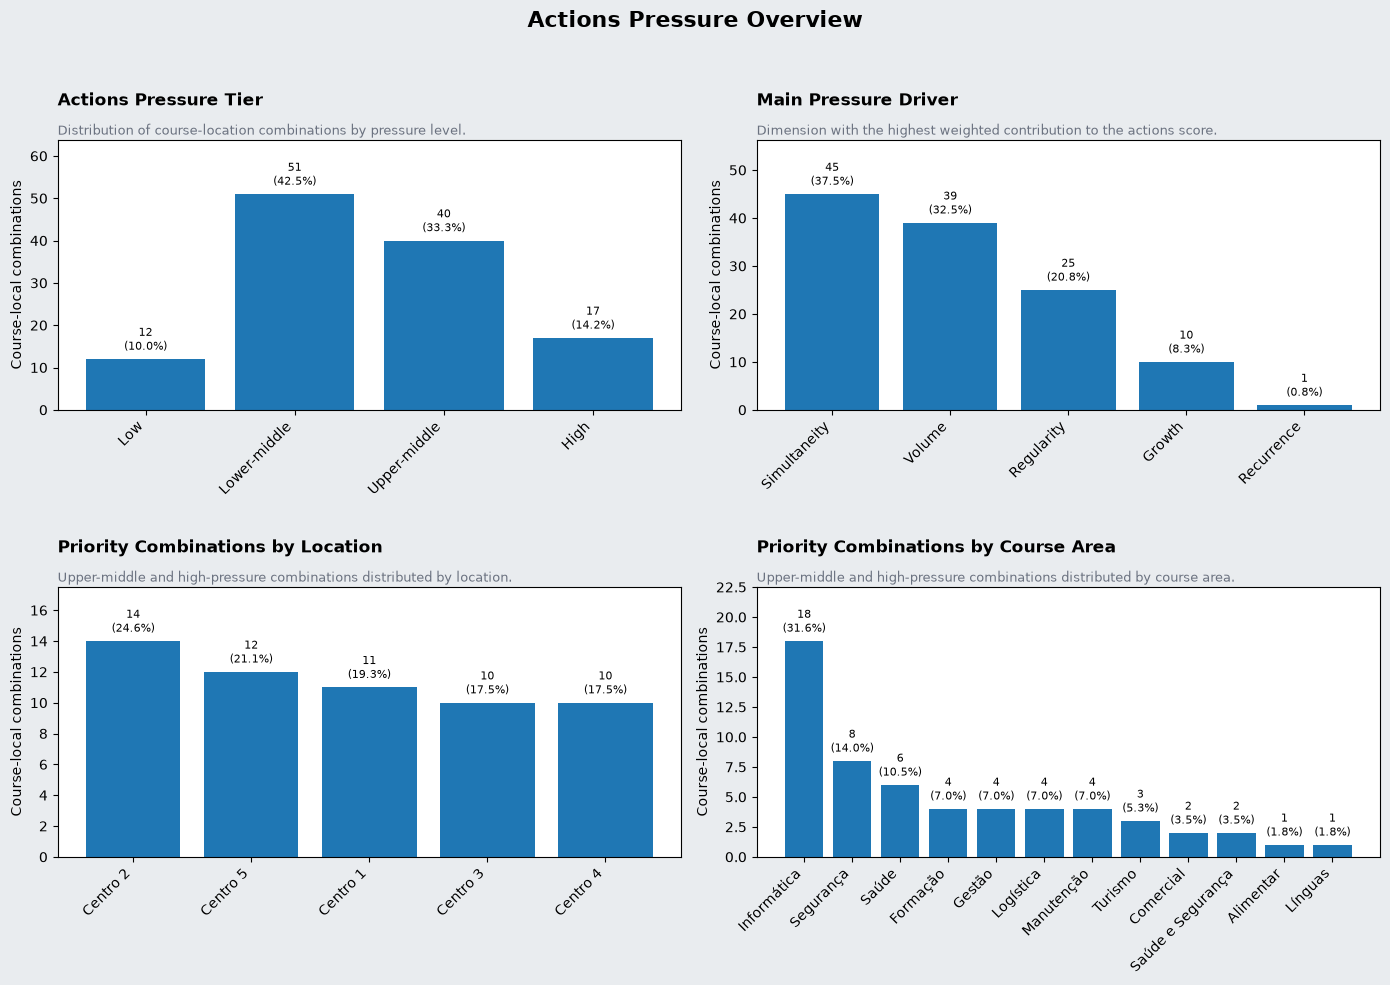

In [107]:
plot_actions_overview(
    charts=actions_score_overview_charts,
    title="Actions Pressure Overview",
    ylabel="Course-local combinations",
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

In [108]:
priority_actions_course_count_df = (
    priority_actions_df
    .groupby(
        [
            "course_id",
            "course_name"
        ],
        as_index=False
    )
    .agg(
        actions_count=(
            "local",
            "nunique"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        [
            "actions_count",
            "course_id"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

priority_actions_course_count_df

,course_id,course_name,actions_count,pct_actions
0,CYB,Cibersegurança Básica,5,8.771930
1,EXC,Excel Aplicado à Gestão,5,8.771930
2,GER,Geriatria e Apoio ao Idoso,5,8.771930
3,PBI,Power BI e Visualização de Dados,5,8.771930
4,SST,Saúde e Segurança no Trabalho,5,8.771930
5,FOR,Formação Pedagógica Inicial de Formadores,4,7.017544
6,LOG,Logística e Gestão de Armazém,4,7.017544
7,MNT,Manutenção Industrial Básica,4,7.017544
8,PYT,Introdução à Programação em Python,3,5.263158
9,HOT,Housekeeping e Operações Hoteleiras,2,3.508772


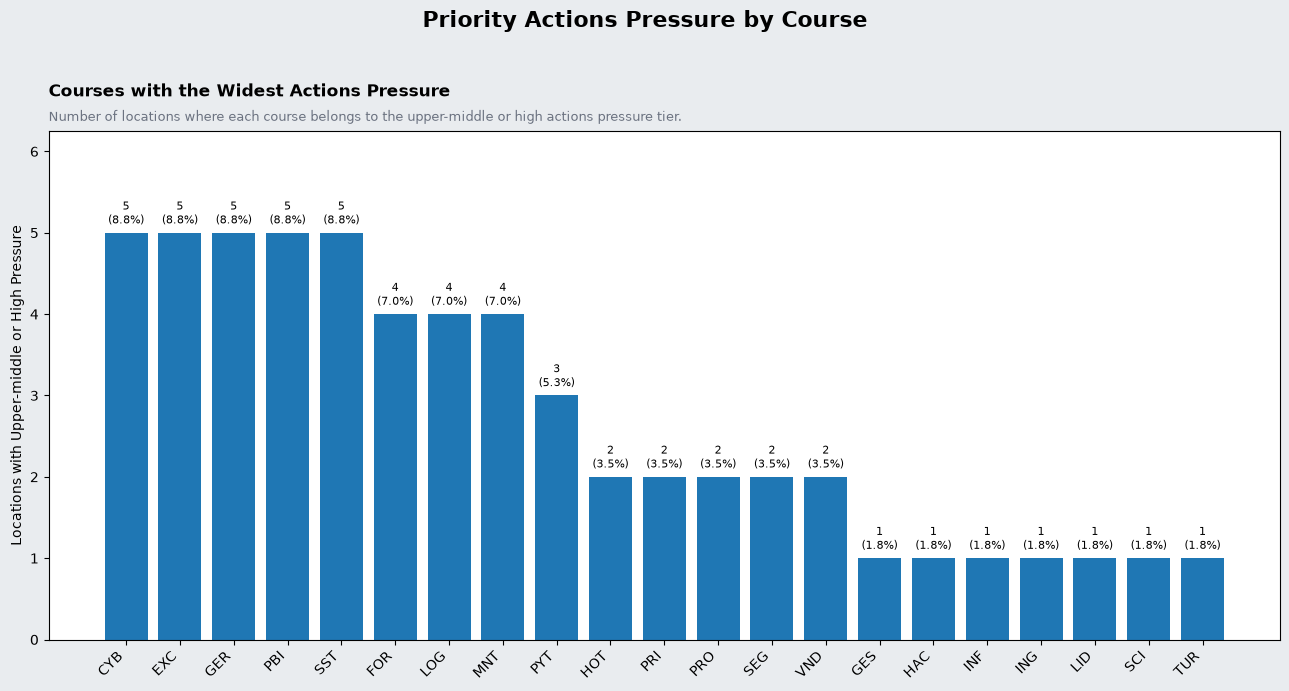

In [109]:
course_actions_pressure_charts = {
    "course_pressure": {
        "df": priority_actions_course_count_df,
        "label_column": "course_id",
        "title": "Courses with the Widest Actions Pressure",
        "description": (
            "Number of locations where each course belongs to "
            "the upper-middle or high actions pressure tier."
        )
    }
}

plot_actions_overview(
    charts=course_actions_pressure_charts,
    title="Priority Actions Pressure by Course",
    ylabel="Locations with Upper-middle or High Pressure",
    nrows=1,
    ncols=1,
    figsize=(13, 7)
)

## Key operational findings

Of the 120 course-location combinations:

- 17 are classified as High pressure;
- 40 are Upper-middle;
- 51 are Lower-middle;
- 12 are Low.

Simultaneity is the main pressure driver for 45 combinations, followed by volume for 39, regularity for 25, growth for 10, and recurrence for one.

The highest operational-pressure combinations include:

- Power BI e Visualização de Dados — Centre 2;
- Cibersegurança Básica — Centre 4;
- Power BI e Visualização de Dados — Centre 4;
- Geriatria e Apoio ao Idoso — Centre 3;
- Excel Aplicado à Gestão — Centre 4;
- Introdução à Programação em Python — Centre 2.

Centre 2 contains the largest number of Upper-middle or High-pressure combinations.

Cibersegurança Básica, Excel Aplicado à Gestão, Geriatria e Apoio ao Idoso, Saúde e Segurança no Trabalho, and Power BI e Visualização de Dados reach at least Upper-middle pressure in all five locations.

These results identify where observed training demand creates the greatest operational pressure. They do not independently establish a recruitment requirement because trainer coverage and commercial demand must also be considered.

## Export operational scores

The operational features, recent and historical dimension scores, weighted contributions, pressure levels, main drivers, and priority ranks are exported to:

`data/scores/actions_scored_features.csv`

This dataset becomes the training-activity input for the final hiring-priority model.

In [110]:
actions_scored_features_df.to_csv(
    SCORES_DATA_DIR / "actions_scored_features.csv",
    index=False,
    encoding="utf-8"
)

## Training actions analysis outcome

The training-actions analysis transformed observed operational activity into a structured assessment of volume, growth, recurrence, regularity, and simultaneity for all 120 course-location combinations.

The results show that operational pressure is driven primarily by concurrent activity and sustained training volume. These factors indicate where existing or future trainer capacity may be most exposed to overlapping demand.

The operational score will next be combined with workforce vulnerability and commercial pressure to determine the overall hiring priority.